In [1]:
import torch
import pandas as pd
from epiweeks import Week
import preprocess_data as prep
import model as mc
import matplotlib.pyplot as plt 


pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Mix of experts: 

In [2]:
regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

columns_to_normalize = ['casos','epiweek', 'biome', 'enso']

predict_n = 30
max_epiweek = 22
    
boxcox = False

TEST_YEAR = 2023


batch_size = 2
epochs = 500
media =True
verbose = 1
doenca = 'dengue'
min_delta = 0.0
patience= 25
lr = 1e-4
min_year = 2015
model_name = f'mix_22_V3'

Load data: 

In [3]:
df = prep.load_cases_data(filename= f'./data/{doenca}.csv.gz')

enso = prep.load_enso_weekly(filename='data/enso_weekly_forecast_up_25_07.csv')

enso_neutro = prep.load_enso_weekly(filename='data/enso_weekly_neutro.csv')

Train model: 

In [4]:
for region in regioes_estados.keys(): 

    print(region)

    label = f'{region}_{TEST_YEAR-1}_{model_name}'

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]


    X_train, y_train, X_future, norm_values, norm_enso =  prep.generate_regional_train_samples(df_reg, enso, 
                                                                                    TEST_YEAR,
                                                                                    max_epiweek = max_epiweek,
                                                                                    columns_to_normalize = columns_to_normalize,
                                                                                    min_year = min_year, 
                                                                                    boxcox = boxcox,
                                                                                    media = media)
    

    base_model  = mc.load_model(region, TEST_YEAR,doenca, 'base_22', predict_n, max_epiweek, device)    

    future_model  = mc.load_model(region, TEST_YEAR,doenca, 'enso_22_V3', predict_n, max_epiweek, device)    

    # congelando o modelo 

    for p in base_model.parameters():
        p.requires_grad = False

    for p in future_model.parameters():
        p.requires_grad = False


    model = mc.MixtureOfExperts(

        model1=base_model,

        model2=future_model,

        hidden_size=64,

        future_cov_size=predict_n,

        predict_n=predict_n,

        gate_hidden=32
    )

    trained_model, hist = mc.train_model(

            model=model,

            X_train=X_train,

            X_future=X_future,

            Y_train=y_train,

            label=label,

            batch_size=batch_size,

            epochs=epochs,

            lr=lr,

            patience=patience,

            verbose=verbose,

            doenca=doenca
)
    



Sul
Epoch 1/500 | Train: 0.0390 | Val: 0.0538
Epoch 2/500 | Train: 0.0392 | Val: 0.0535
Epoch 3/500 | Train: 0.0410 | Val: 0.0532
Epoch 4/500 | Train: 0.0405 | Val: 0.0527
Epoch 5/500 | Train: 0.0384 | Val: 0.0524
Epoch 6/500 | Train: 0.0369 | Val: 0.0519
Epoch 7/500 | Train: 0.0371 | Val: 0.0515
Epoch 8/500 | Train: 0.0370 | Val: 0.0510
Epoch 9/500 | Train: 0.0376 | Val: 0.0506
Epoch 10/500 | Train: 0.0361 | Val: 0.0501
Epoch 11/500 | Train: 0.0361 | Val: 0.0497
Epoch 12/500 | Train: 0.0357 | Val: 0.0493
Epoch 13/500 | Train: 0.0351 | Val: 0.0488
Epoch 14/500 | Train: 0.0342 | Val: 0.0486
Epoch 15/500 | Train: 0.0342 | Val: 0.0483
Epoch 16/500 | Train: 0.0337 | Val: 0.0481
Epoch 17/500 | Train: 0.0343 | Val: 0.0479
Epoch 18/500 | Train: 0.0336 | Val: 0.0477
Epoch 19/500 | Train: 0.0345 | Val: 0.0476
Epoch 20/500 | Train: 0.0329 | Val: 0.0475
Epoch 21/500 | Train: 0.0340 | Val: 0.0474
Epoch 22/500 | Train: 0.0333 | Val: 0.0473
Epoch 23/500 | Train: 0.0326 | Val: 0.0472
Epoch 24/500 | T

In [5]:
X_train.shape

torch.Size([225, 74, 5])

In [6]:
X_train[0, :, -1].shape

torch.Size([74])

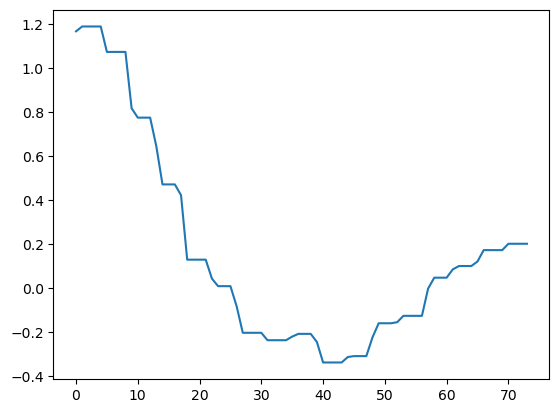

In [7]:
plt.plot(X_train[0, :, 3])